# ARTI 308 - Lab 5 Solution: Feature Engineering (Classification)
## Content Type Prediction using Netflix Titles Dataset

## 1. Setup and imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

## 2. Load the dataset

In [2]:
DATA_PATH = '../data/netflix_titles.csv'
df = pd.read_csv(DATA_PATH)
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 3. Quick dataset checks

In [3]:
print('Shape:', df.shape)
print('\nMissing values per column:')
display(df.isna().sum().to_frame('missing_count').T)
print('\nDuplicate rows:', df.duplicated().sum())

Shape: (8807, 12)

Missing values per column:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
missing_count,0,0,0,2634,825,831,10,0,4,3,0,0



Duplicate rows: 0


The dataset has missing values in some metadata columns, so we will handle this during feature engineering and preprocessing.

## 4. Target variable and class balance

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


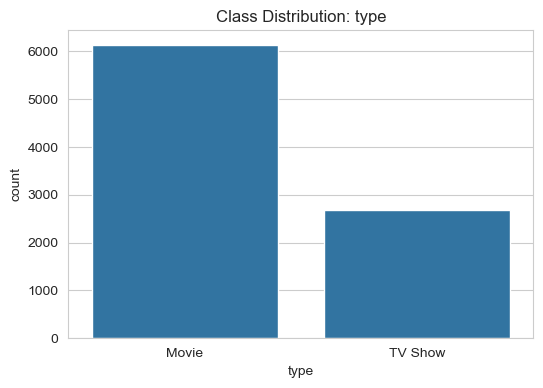

In [4]:
target_col = 'type'
print(df[target_col].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.title('Class Distribution: type')
plt.show()

## 5. Identify feature types

In [5]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

## 6. Leakage awareness (important)
When predicting `type`, we avoid direct leakage features like raw `duration`/`duration_unit` because values such as `min` vs `Season(s)` almost directly reveal the target.

## 7. Feature engineering

### 7.1 Time-based features from `date_added`

In [6]:
df_fe = df.copy()

df_fe['date_added_dt'] = pd.to_datetime(df_fe['date_added'], errors='coerce')
df_fe['added_year'] = df_fe['date_added_dt'].dt.year
df_fe['added_month'] = df_fe['date_added_dt'].dt.month

# Weekend vs weekday addition
df_fe['added_dayofweek'] = df_fe['date_added_dt'].dt.dayofweek
df_fe['added_is_weekend'] = df_fe['added_dayofweek'].isin([5, 6]).astype('Int64')

df_fe[['date_added', 'added_year', 'added_month', 'added_dayofweek', 'added_is_weekend']].head()

,date_added,added_year,added_month,added_dayofweek,added_is_weekend
0,"September 25, 2021",2021.0,9.0,5.0,1
1,"September 24, 2021",2021.0,9.0,4.0,0
2,"September 24, 2021",2021.0,9.0,4.0,0
3,"September 24, 2021",2021.0,9.0,4.0,0
4,"September 24, 2021",2021.0,9.0,4.0,0


### 7.2 Text/metadata-derived features

In [7]:
df_fe['title_word_count'] = df_fe['title'].fillna('').str.split().str.len()
df_fe['description_word_count'] = df_fe['description'].fillna('').str.split().str.len()
df_fe['cast_count'] = df_fe['cast'].fillna('').str.split(',').apply(lambda x: 0 if x == [''] else len(x))
df_fe['country_count'] = df_fe['country'].fillna('').str.split(',').apply(lambda x: 0 if x == [''] else len(x))

# Keep first listed genre as a reduced category
df_fe['primary_genre'] = df_fe['listed_in'].fillna('').str.split(',').str[0].str.strip()

df_fe[['title_word_count', 'description_word_count', 'cast_count', 'country_count', 'primary_genre']].head()

,title_word_count,description_word_count,cast_count,country_count,primary_genre
0,4,27,0,1,Documentaries
1,3,27,19,1,International TV Shows
2,1,27,9,0,Crime TV Shows
3,3,24,0,0,Docuseries
4,2,24,8,1,International TV Shows


### 7.3 Optional cardinality reduction (`director`)

In [8]:
top_k = 25
top_directors = df_fe['director'].value_counts(dropna=True).head(top_k).index
df_fe['director_reduced'] = np.where(df_fe['director'].isin(top_directors), df_fe['director'], 'Other')
df_fe['director_reduced'] = df_fe['director_reduced'].fillna('Unknown')

df_fe[['director', 'director_reduced']].head(10)

,director,director_reduced
0,Kirsten Johnson,Other
1,NaN,Other
2,Julien Leclercq,Other
3,NaN,Other
4,NaN,Other
5,Mike Flanagan,Other
6,"Robert Cullen, José Luis Ucha",Other
7,Haile Gerima,Other
8,Andy Devonshire,Other
9,Theodore Melfi,Other


## 8. Discretization (binning)
We bin `release_year` into eras for a more interpretable categorical signal.

In [9]:
df_fe['release_era'] = pd.cut(
    df_fe['release_year'],
    bins=[1900, 1980, 2000, 2010, 2015, 2020, 2030],
    labels=['Classic', 'Old', 'Early-Modern', '2010-2015', '2016-2020', 'Recent'],
    include_lowest=True
)

df_fe[['release_year', 'release_era']].head(10)

,release_year,release_era
0,2020,2016-2020
1,2021,Recent
2,2021,Recent
3,2021,Recent
4,2021,Recent
5,2021,Recent
6,2021,Recent
7,1993,Old
8,2021,Recent
9,2021,Recent


## 9. Prepare features for modeling

In [10]:
drop_cols = [
    'show_id', 'type', 'title', 'description', 'date_added', 'date_added_dt',
    'duration', 'listed_in', 'added_dayofweek'
]

X = df_fe.drop(columns=drop_cols, errors='ignore')
y = df_fe[target_col]

print('X shape:', X.shape)
print('y shape:', y.shape)
print('\nColumns used:')
print(X.columns.tolist())

X shape: (8807, 15)
y shape: (8807,)

Columns used:
['director', 'cast', 'country', 'release_year', 'rating', 'added_year', 'added_month', 'added_is_weekend', 'title_word_count', 'description_word_count', 'cast_count', 'country_count', 'primary_genre', 'director_reduced', 'release_era']


## 10. Split into train and test sets

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Train:', X_train.shape, y_train.shape)
print('Test :', X_test.shape, y_test.shape)

Train: (7045, 15) (7045,)
Test : (1762, 15) (1762,)


## 11. Encoding and baseline model (Random Forest)

In [12]:
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number, 'Int64', 'float64', 'int64']).columns.tolist()

print('Categorical columns:', categorical_cols)
print('Numeric columns:', numeric_cols)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('clf', RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced'))
])

Categorical columns: ['director', 'cast', 'country', 'rating', 'primary_genre', 'director_reduced', 'release_era']
Numeric columns: ['release_year', 'added_year', 'added_month', 'added_is_weekend', 'title_word_count', 'description_word_count', 'cast_count', 'country_count']


## 12. Train the model and evaluate

In [13]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f'Accuracy: {acc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.9983

Classification Report:
              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1227
     TV Show       1.00      0.99      1.00       535

    accuracy                           1.00      1762
   macro avg       1.00      1.00      1.00      1762
weighted avg       1.00      1.00      1.00      1762



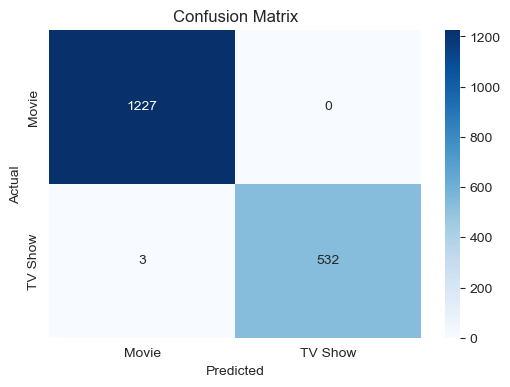

In [14]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## 13. Feature importance (What mattered the most?)

In [15]:
ohe = model.named_steps['preprocess'].named_transformers_['cat'].named_steps['onehot']
cat_feature_names = ohe.get_feature_names_out(categorical_cols) if len(categorical_cols) > 0 else np.array([])
all_feature_names = np.concatenate([np.array(numeric_cols), cat_feature_names])

importances = model.named_steps['clf'].feature_importances_
fi = pd.DataFrame({'feature': all_feature_names, 'importance': importances})
fi = fi.sort_values('importance', ascending=False)
fi.head(15)

,feature,importance
2827,director_Rajiv Chilaka,0.244811
10649,primary_genre_International TV Shows,0.057919
10645,primary_genre_Dramas,0.050785
10640,primary_genre_Comedies,0.036797
10643,primary_genre_Documentaries,0.031189
10641,primary_genre_Crime TV Shows,0.030766
10650,primary_genre_Kids' TV,0.027082
10633,primary_genre_Action & Adventure,0.024010
6,cast_count,0.021230
10624,rating_R,0.018962


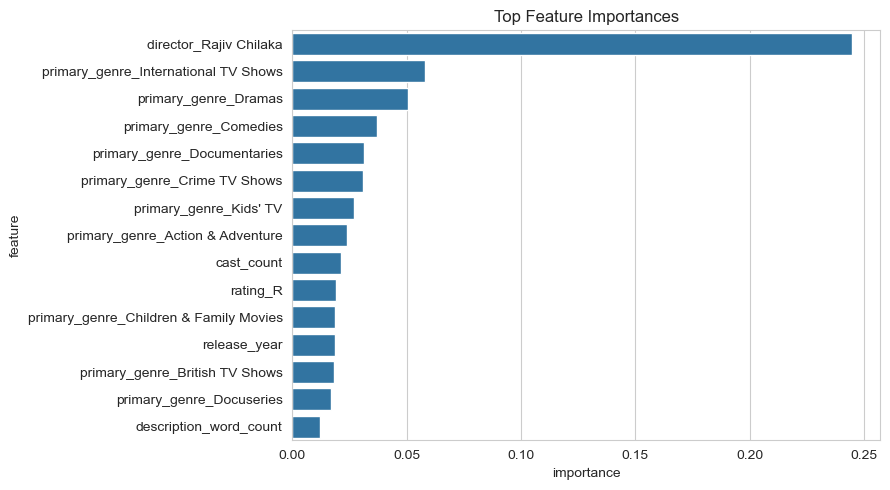

In [16]:
top_n = 15
plt.figure(figsize=(9,5))
sns.barplot(data=fi.head(top_n), x='importance', y='feature')
plt.title('Top Feature Importances')
plt.tight_layout()
plt.show()

## 14. Optional: Feature selection using SelectFromModel

In [17]:
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression

selector_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('select', SelectFromModel(LogisticRegression(max_iter=1000, class_weight='balanced'))),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

selector_model.fit(X_train, y_train)
y_pred_sel = selector_model.predict(X_test)

print('Accuracy after selection (LogReg pipeline):', round(accuracy_score(y_test, y_pred_sel), 4))

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy after selection (LogReg pipeline): 1.0


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 15. Student task (completed)
### Task 1
New engineered feature used: `primary_genre` (first category from `listed_in`).

Justification: `primary_genre` compresses the high-dimensional `listed_in` text into a consistent, business-meaningful category that captures whether content is mainly documentary, drama, kids, action, etc. This improves learnability compared with raw comma-separated multi-label text and helps the classifier separate `Movie` and `TV Show` using genre tendencies while keeping feature dimensionality manageable.

## Wrap-up
This notebook reproduces Lab 5 feature engineering and classification workflow on the Netflix dataset, with leakage-aware feature design and a validated baseline classifier.